In [3]:
!pip install openpyxl

mambajs 0.21.4

Process pip requirements ...



In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy openpyxl mysql-connector-python sqlalchemy


In [ ]:
!mamba install  pandas numpy openpyxl

In [ ]:
!pip install openpyxl


In [ ]:
!pip install --upgrade openpyxl


In [5]:
%mamba install pandas



mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.876 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.6    np23py313h124dbc7_0  emscripten-forge-4x
+ python-tzdata  2026.4   pyh5ded981_0         conda-forge
- pip            26.2.1   pyh145f28c_0         conda-forge


In [6]:
%pip install openpyxl


mambajs 0.21.4

Process pip requirements ...

Requirement openpyxl already satisfied.


In [7]:
import pandas as pd
file_path = 'online_retail.xlsx'
df = pd.read_excel(file_path)
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [15]:
import sqlite3
import pandas as pd

print("💾 Creating a fast, memory-safe SQL database...")
# ':memory:' builds the database inside RAM, bypassing the broken online disk entirely!
conn = sqlite3.connect(':memory:')

try:
    # 1. Load the existing clean DataFrame directly into RAM SQL
    df.to_sql('sales', conn, if_exists='replace', index=False)
    print("🎉 SUCCESS! The 'sales' table is now live in SQL memory.")
    
    # 2. RUN PROJECT QUERY 1: High-Level KPI Summary
    kpi_query = """
    SELECT 
        COUNT(DISTINCT Invoice) as Total_Orders,
        COUNT(DISTINCT Customer_ID) as Total_Customers,
        ROUND(SUM(TotalSales), 2) as Gross_Revenue,
        COUNT(DISTINCT Country) as Countries_Served
    FROM sales;
    """
    print("\n============== 📊 BUSINESS REVENUE SUMMARY ==============")
    df_kpi = pd.read_sql_query(kpi_query, conn)
    print(df_kpi.to_string(index=False))

    # 3. RUN PROJECT QUERY 2: Top 5 Best Selling Products
    top_products_query = """
    SELECT 
        Description, 
        SUM(Quantity) as Units_Sold, 
        ROUND(SUM(TotalSales), 2) as Revenue
    FROM sales
    GROUP BY Description
    ORDER BY Revenue DESC
    LIMIT 5;
    """
    print("\n============== 🏆 TOP 5 PRODUCTS BY REVENUE ==============")
    df_top = pd.read_sql_query(top_products_query, conn)
    print(df_top.to_string(index=False))

except Exception as e:
    print("\n❌ IN-MEMORY SQL FAILED:")
    print(str(e))


💾 Creating a fast, memory-safe SQL database...
🎉 SUCCESS! The 'sales' table is now live in SQL memory.

============== 📊 BUSINESS REVENUE SUMMARY ==============
 Total_Orders  Total_Customers  Gross_Revenue  Countries_Served
        19213             4312     8832003.27                37

============== 🏆 TOP 5 PRODUCTS BY REVENUE ==============
                       Description  Units_Sold   Revenue
WHITE HANGING HEART T-LIGHT HOLDER       56915 151624.31
          REGENCY CAKESTAND 3 TIER       12497 143893.35
                            Manual        2630  98560.64
     ASSORTED COLOUR BIRD ORNAMENT       44551  70493.83
           JUMBO BAG RED RETROSPOT       29578  51759.30


In [18]:
%pip install seaborn


mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


=================== 📊 EXECUTIVE KPIs ===================
 Total_Orders  Total_Customers  Gross_Revenue  Countries_Served
        19213             4312     8832003.27                37

=================== 🏆 TOP 5 PRODUCTS ===================
                       Description  Units_Sold   Revenue
WHITE HANGING HEART T-LIGHT HOLDER       56915 151624.31
          REGENCY CAKESTAND 3 TIER       12497 143893.35
                            Manual        2630  98560.64
     ASSORTED COLOUR BIRD ORNAMENT       44551  70493.83
           JUMBO BAG RED RETROSPOT       29578  51759.30

=================== 📅 MONTHLY REVENUE TRENDS ===================
  Month  Monthly_Revenue
2009-12        686654.16
2010-01        557319.06
2010-02        506371.07
2010-03        699608.99
2010-04        594609.19
2010-05        599985.79
2010-06        639066.58
2010-07        591636.74
2010-08        604242.65
2010-09        831615.00
2010-10       1036680.00
2010-11       1172336.04
2010-12        311878.00

/tmp/xpython_42/3544963595.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, x='Revenue', y='Description', palette='Blues_r', ax=axes[0,1])


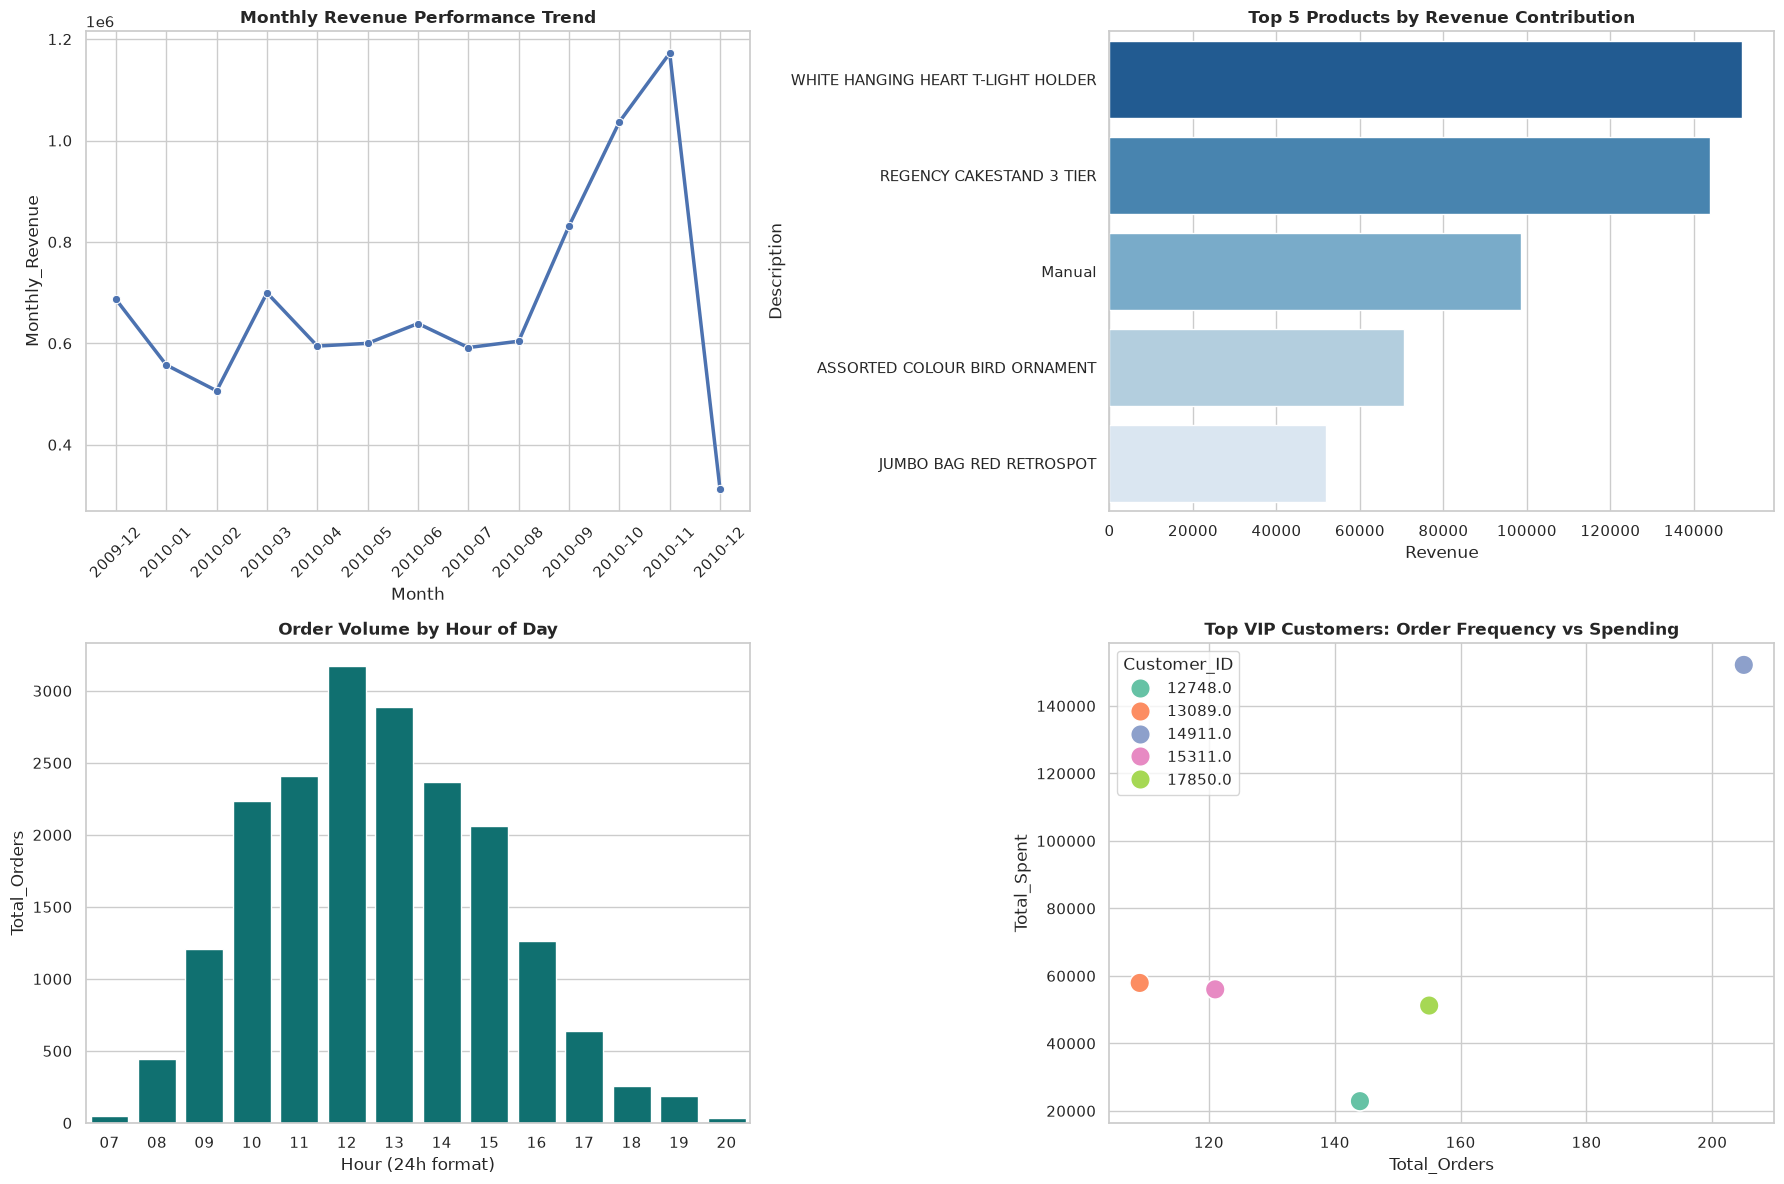

In [20]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 2. THE SQL QUERY SUITE
# ==============================================================================

# Query 1: High Level Executive Summary KPIs
kpi_query = """
SELECT 
    COUNT(DISTINCT Invoice) as Total_Orders,
    COUNT(DISTINCT Customer_ID) as Total_Customers,
    ROUND(SUM(TotalSales), 2) as Gross_Revenue,
    COUNT(DISTINCT Country) as Countries_Served
FROM sales;
"""
print("=================== 📊 EXECUTIVE KPIs ===================")
df_kpi = pd.read_sql_query(kpi_query, conn)
print(df_kpi.to_string(index=False))

# Query 2: Top 5 Products by Revenue
top_products_query = """
SELECT 
    Description, 
    SUM(Quantity) as Units_Sold, 
    ROUND(SUM(TotalSales), 2) as Revenue
FROM sales
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 5;
"""
print("\n=================== 🏆 TOP 5 PRODUCTS ===================")
df_top = pd.read_sql_query(top_products_query, conn)
print(df_top.to_string(index=False))

# Query 3: Monthly Revenue Trends over Time
monthly_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) as Month, 
    ROUND(SUM(TotalSales), 2) as Monthly_Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
"""
print("\n=================== 📅 MONTHLY REVENUE TRENDS ===================")
df_monthly = pd.read_sql_query(monthly_query, conn)
print(df_monthly.to_string(index=False))

# Query 4: Hourly Purchase Volume Spikes
hourly_query = """
SELECT 
    strftime('%H', InvoiceDate) as Hour_of_Day,
    COUNT(DISTINCT Invoice) as Total_Orders,
    ROUND(SUM(TotalSales), 2) as Hourly_Revenue
FROM sales
GROUP BY Hour_of_Day
ORDER BY Hour_of_Day;
"""
print("\n=================== ⏰ HOURLY TRANSACTION SPIKES ===================")
df_hourly = pd.read_sql_query(hourly_query, conn)
print(df_hourly.to_string(index=False))

# Query 5: Customer Loyalty Breakdown
loyalty_query = """
SELECT 
    Customer_ID,
    Country,
    COUNT(DISTINCT Invoice) as Total_Orders,
    ROUND(SUM(TotalSales), 2) as Total_Spent
FROM sales
GROUP BY Customer_ID
ORDER BY Total_Orders DESC
LIMIT 5;
"""
print("\n=================== 💎 TOP 5 LOYAL CUSTOMERS ===================")
df_loyalty = pd.read_sql_query(loyalty_query, conn)
print(df_loyalty.to_string(index=False))

# ==============================================================================
# 3. GRAPH VISUALIZATIONS
# ==============================================================================
print("\n📈 Rendering Visual Analytics Dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart A: Line graph for Monthly Sales
sns.lineplot(data=df_monthly, x='Month', y='Monthly_Revenue', marker='o', color='b', linewidth=2.5, ax=axes[0,0])
axes[0,0].set_title('Monthly Revenue Performance Trend', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart B: Horizontal Bar Chart for Top Products
sns.barplot(data=df_top, x='Revenue', y='Description', palette='Blues_r', ax=axes[0,1])
axes[0,1].set_title('Top 5 Products by Revenue Contribution', fontsize=12, fontweight='bold')

# Chart C: Bar Chart for Hourly Spikes
sns.barplot(data=df_hourly, x='Hour_of_Day', y='Total_Orders', color='teal', ax=axes[1,0])
axes[1,0].set_title('Order Volume by Hour of Day', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Hour (24h format)')

# Chart D: Customer Retention Focus (Spending vs Volume)
sns.scatterplot(data=df_loyalty, x='Total_Orders', y='Total_Spent', hue='Customer_ID', s=200, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Top VIP Customers: Order Frequency vs Spending', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
